# Checkpoint Loss Curves

This notebook reads the analysis files generated by `scripts/eval_checkpointing_losses.py` and plots training loss against a unified validation-loss curve from `merged_loss_curves` for the APRIL infilling experiments.

Expected default outputs:
- `outputs/analysis/checkpoint_loss_curves/merged_loss_curves.csv`
- `outputs/analysis/checkpoint_loss_curves/run_manifest.json`

If you wrote results somewhere else, update `ANALYSIS_DIR` in the next cell.

In [19]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "outputs").exists():
    REPO_ROOT = Path("/groups/tensorlab/myang2/cs165-project")

ANALYSIS_DIR = REPO_ROOT / "outputs" / "analysis" / "checkpoint_loss_curves"
MERGED_CSV = ANALYSIS_DIR / "merged_loss_curves.csv"
MANIFEST_JSON = ANALYSIS_DIR / "run_manifest.json"

if not MERGED_CSV.exists():
    raise FileNotFoundError(
        f"Could not find {MERGED_CSV}. Run scripts/eval_checkpointing_losses.py first."
    )
if not MANIFEST_JSON.exists():
    raise FileNotFoundError(
        f"Could not find {MANIFEST_JSON}. Run scripts/eval_checkpointing_losses.py first."
    )

loss_df = pd.read_csv(MERGED_CSV)
with MANIFEST_JSON.open("r", encoding="utf-8") as handle:
    manifest = json.load(handle)

loss_df["epoch"] = pd.to_numeric(loss_df.get("epoch"), errors="coerce")
loss_df["step"] = pd.to_numeric(loss_df.get("step"), errors="coerce")
loss_df["loss_value"] = pd.to_numeric(loss_df.get("loss_value"), errors="coerce")
loss_df["requested_epoch"] = pd.to_numeric(
    loss_df.get("requested_epoch"), errors="coerce"
)

experiment_order = [row["experiment_name"] for row in manifest.get("experiments", [])]
if not experiment_order:
    experiment_order = sorted(loss_df["experiment_name"].dropna().unique())

print(f"Loaded {len(loss_df):,} rows from {MERGED_CSV}")
display(loss_df.head())

Loaded 13,801 rows from /groups/tensorlab/myang2/cs165-project/outputs/analysis/checkpoint_loss_curves/merged_loss_curves.csv


,experiment_name,experiment_dir,model_family,source,epoch,step,checkpoint_path,metric_name,loss_value,eval_runtime,...,eval_steps_per_second,requested_epoch,global_step,status,checkpoint_name,checkpoint_step,dataset_path,weight_filename,error_message,num_eval_examples
0,infilling-diffusion-april-thme-train100k-val10k,/resnick/groups/tensorlab/myang2/cs165-project...,diffusion,trainer_state,0.0032,10.0,/resnick/groups/tensorlab/myang2/cs165-project...,train_loss,1.3159,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,infilling-diffusion-april-thme-train100k-val10k,/resnick/groups/tensorlab/myang2/cs165-project...,diffusion,trainer_state,0.0064,20.0,/resnick/groups/tensorlab/myang2/cs165-project...,train_loss,1.1457,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,infilling-diffusion-april-thme-train100k-val10k,/resnick/groups/tensorlab/myang2/cs165-project...,diffusion,trainer_state,0.0096,30.0,/resnick/groups/tensorlab/myang2/cs165-project...,train_loss,1.0782,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,infilling-diffusion-april-thme-train100k-val10k,/resnick/groups/tensorlab/myang2/cs165-project...,diffusion,trainer_state,0.0128,40.0,/resnick/groups/tensorlab/myang2/cs165-project...,train_loss,0.9429,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,infilling-diffusion-april-thme-train100k-val10k,/resnick/groups/tensorlab/myang2/cs165-project...,diffusion,trainer_state,0.0160,50.0,/resnick/groups/tensorlab/myang2/cs165-project...,train_loss,0.7945,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
VAL_METRICS = ["logged_eval_loss", "checkpoint_val_loss"]


def rows_for_metric(experiment_name: str, metric_name: str) -> pd.DataFrame:
    rows = loss_df[
        (loss_df["experiment_name"] == experiment_name)
        & (loss_df["metric_name"] == metric_name)
    ].copy()
    return rows.sort_values(["step", "epoch"])


def model_family_for_experiment(experiment_name: str) -> str:
    rows = loss_df[loss_df["experiment_name"] == experiment_name]
    if rows.empty:
        return ""
    families = rows["model_family"].dropna()
    return str(families.iloc[0]) if not families.empty else ""


def train_rows_for_plot(experiment_name: str) -> pd.DataFrame:
    rows = rows_for_metric(experiment_name, "train_loss")
    if model_family_for_experiment(experiment_name) == "diffusion":
        rows = rows[rows["epoch"] <= 20]
    return rows


def val_rows_for_experiment(experiment_name: str) -> pd.DataFrame:
    rows = loss_df[
        (loss_df["experiment_name"] == experiment_name)
        & (loss_df["metric_name"].isin(VAL_METRICS))
        & loss_df["loss_value"].notna()
    ].copy()
    rows = rows.sort_values(["epoch", "step", "metric_name"])
    rows = rows.drop_duplicates(subset=["epoch", "step", "loss_value"], keep="last")
    return rows


def missing_epoch_rows(experiment_name: str) -> pd.DataFrame:
    rows = loss_df[
        (loss_df["experiment_name"] == experiment_name)
        & (loss_df["metric_name"] == "checkpoint_val_loss")
        & loss_df["loss_value"].isna()
    ].copy()
    return rows.sort_values(["requested_epoch", "epoch"])


def plot_experiment(experiment_name: str, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    train_rows = train_rows_for_plot(experiment_name)
    val_rows = val_rows_for_experiment(experiment_name)
    missing_rows = missing_epoch_rows(experiment_name)
    model_family = model_family_for_experiment(experiment_name)

    val_ax = ax
    use_separate_val_axis = model_family == "diffusion" and not val_rows.empty
    if use_separate_val_axis:
        val_ax = ax.twinx()

    if not train_rows.empty:
        ax.plot(
            train_rows["epoch"],
            train_rows["loss_value"],
            label="train loss",
            color="tab:blue",
            linewidth=1.6,
            alpha=0.9,
        )
    if not val_rows.empty:
        val_ax.plot(
            val_rows["epoch"],
            val_rows["loss_value"],
            label="val loss",
            color="tab:orange",
            marker="o",
            linewidth=1.6,
            alpha=0.9,
        )

    if model_family != "ar" and not missing_rows.empty:
        missing_epochs = ", ".join(
            str(int(epoch)) for epoch in missing_rows["requested_epoch"].dropna().tolist()
        )
        ax.text(
            0.99,
            0.02,
            f"missing checkpoint epochs: {missing_epochs}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=9,
            color="tab:red",
        )

    ax.set_title(experiment_name)
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.25)

    if use_separate_val_axis:
        ax.set_ylabel("train loss", color="tab:blue")
        val_ax.set_ylabel("val loss", color="tab:orange")
        ax.tick_params(axis="y", labelcolor="tab:blue")
        val_ax.tick_params(axis="y", labelcolor="tab:orange")
        train_handles, train_labels = ax.get_legend_handles_labels()
        val_handles, val_labels = val_ax.get_legend_handles_labels()
        ax.legend(train_handles + val_handles, train_labels + val_labels, loc="upper center")
    else:
        ax.set_ylabel("loss")
        ax.legend()


def checkpoint_summary_table() -> pd.DataFrame:
    rows = []
    for experiment_name in experiment_order:
        train_rows = rows_for_metric(experiment_name, "train_loss")
        val_rows = val_rows_for_experiment(experiment_name)
        missing_rows = missing_epoch_rows(experiment_name)
        rows.append(
            {
                "experiment_name": experiment_name,
                "num_train_points": len(train_rows),
                "num_val_points": len(val_rows),
                "min_val_epoch": val_rows["epoch"].min() if not val_rows.empty else None,
                "max_val_epoch": val_rows["epoch"].max() if not val_rows.empty else None,
                "missing_requested_epochs": ", ".join(
                    str(int(epoch))
                    for epoch in missing_rows["requested_epoch"].dropna().tolist()
                ),
            }
        )
    return pd.DataFrame(rows)

,experiment_name,num_train_points,num_val_points,min_val_epoch,max_val_epoch,missing_requested_epochs
0,infilling-diffusion-april-thme-train100k-val10k,8125,22,1.0,20.0,
1,infilling-ar-april-thme-train100k-val10k,5625,13,1.0,9.0,"10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20"


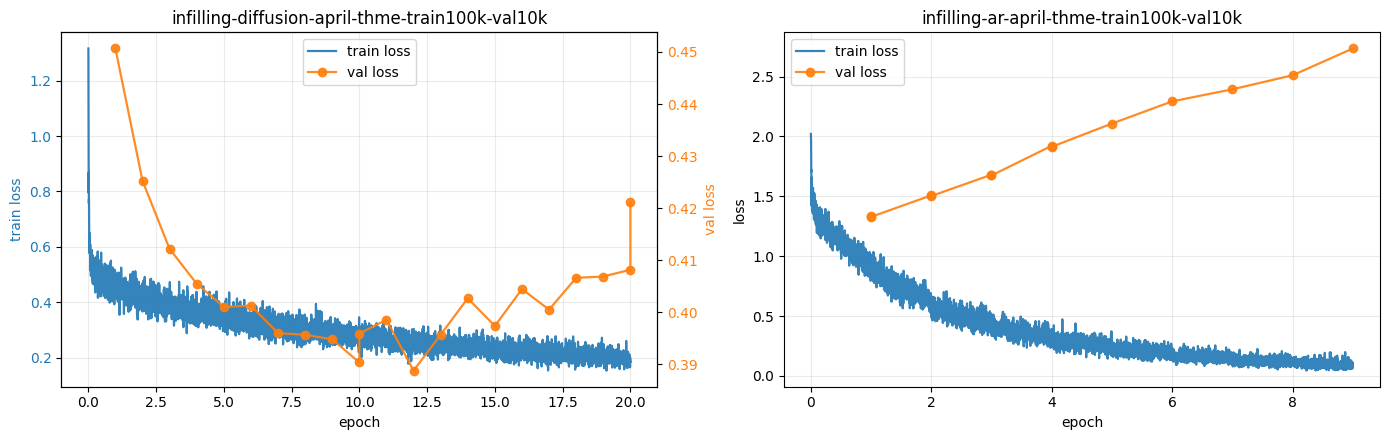

In [21]:
summary_df = checkpoint_summary_table()
display(summary_df)

num_experiments = max(1, len(experiment_order))
num_cols = 2
num_rows = (num_experiments + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 4.5 * num_rows), squeeze=False)

for ax, experiment_name in zip(axes.flatten(), experiment_order):
    plot_experiment(experiment_name, ax=ax)

for ax in axes.flatten()[len(experiment_order):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

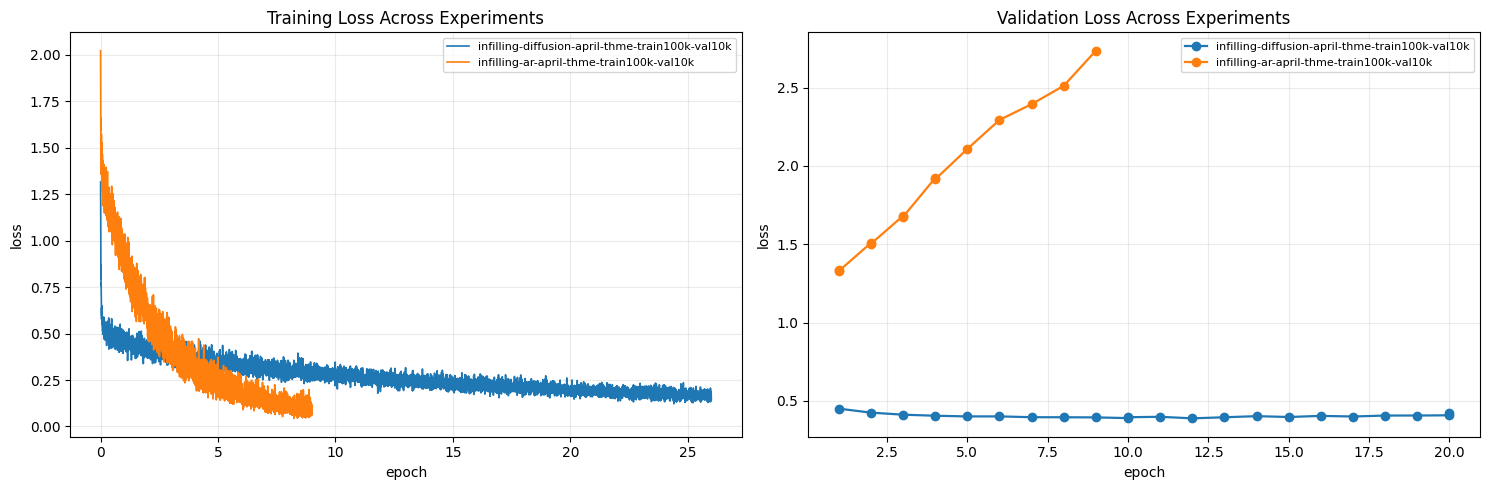

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for experiment_name in experiment_order:
    train_rows = rows_for_metric(experiment_name, "train_loss")
    val_rows = val_rows_for_experiment(experiment_name)

    if not train_rows.empty:
        axes[0].plot(
            train_rows["epoch"],
            train_rows["loss_value"],
            label=experiment_name,
            linewidth=1.2,
        )
    if not val_rows.empty:
        axes[1].plot(
            val_rows["epoch"],
            val_rows["loss_value"],
            marker="o",
            label=experiment_name,
            linewidth=1.6,
        )

axes[0].set_title("Training Loss Across Experiments")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].set_title("Validation Loss Across Experiments")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].grid(True, alpha=0.25)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

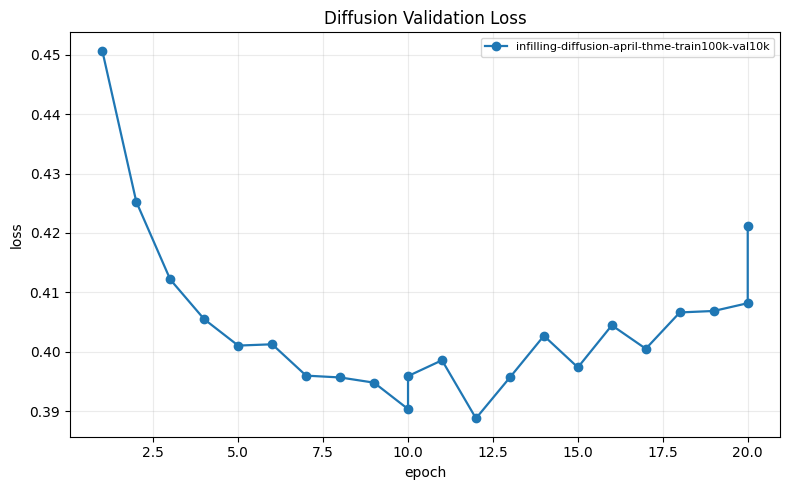

In [23]:
diffusion_experiments = [
    name for name in experiment_order if model_family_for_experiment(name) == "diffusion"
]

fig, ax = plt.subplots(figsize=(8, 5))

for experiment_name in diffusion_experiments:
    val_rows = val_rows_for_experiment(experiment_name)
    if not val_rows.empty:
        ax.plot(
            val_rows["epoch"],
            val_rows["loss_value"],
            marker="o",
            linewidth=1.6,
            label=experiment_name,
        )
        

ax.set_title("Diffusion Validation Loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.25)
if diffusion_experiments:
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()